## Ejercicio 1
Es de gran utilidad obtener una aproximaci´on a la respuesta del
tracto vocal, ya que ´esta permite estimar a partir de los sucesivos m´aximos
de este espectro, los valores de las frecuencias formantes de cada fonema.
En el archivo aeiou.txt se encuentra una se˜nal de voz registrada durante la
emisi´on de las vocales /a/, /e/, /i/, /o/ y /u/, con frecuencia de muestreo
8000 Hz. Se desea aplicar un liftrado para obtener aproximaciones de la
respuesta en frecuencia del tracto vocal, para cada una de las vocales. Realice
el liftrado suponiendo que la informaci´on de la respuesta del tracto vocal se
encuentra en los primeros 20 coeficientes en el dominio de las cuefrencias, y
luego rep´ıtalo suponiendo que se encuentra en los primeros 40 coeficientes.
Para todos c´alculos se recomienda utilizar 1024 muestras de la parte central
(estable) de cada vocal.
Utilice la estimaci´on de las respuestas del tracto vocal a partir del liftro con
20 coeficientes para determinar las dos primeras formantes (F1 y F2) de las
cinco vocales.

In [462]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.signal import find_peaks
import librosa
from scipy.signal import freqz

In [463]:
x = np.loadtxt('data/aeiou_mas.txt')

<Axes: >

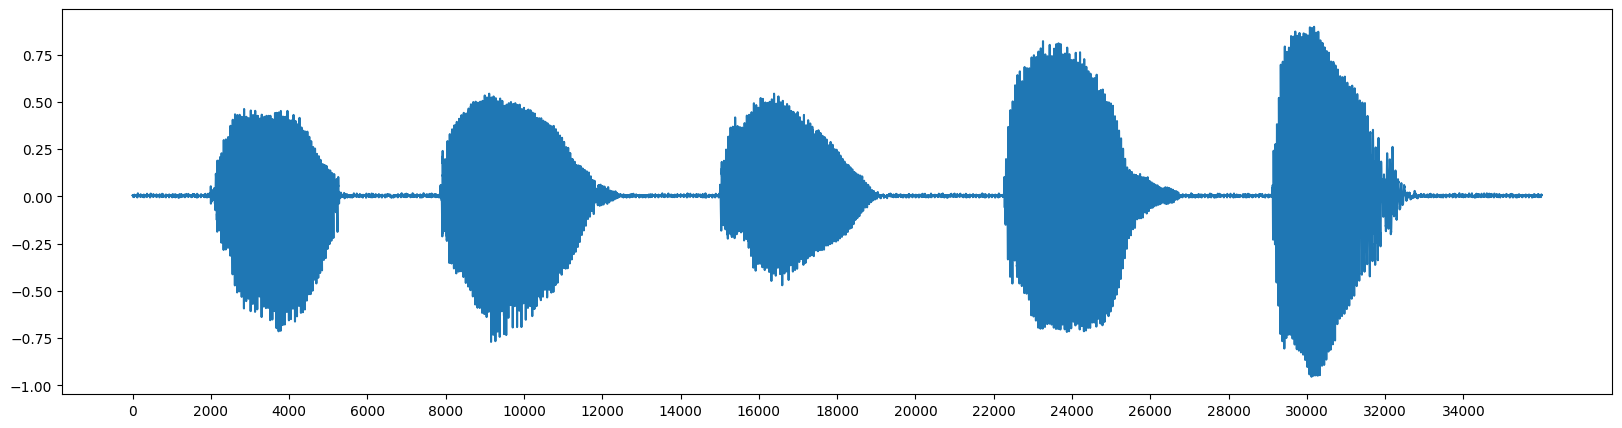

In [464]:
plt.figure(figsize=(20,5))
plt.xticks(np.arange(0, len(x), 2000))
sns.lineplot(x)


In [465]:
window_duration_ms = 20

In [466]:
def preparar_segmento(seg, a=0.97):    
    # # 1. Remoción de la media
    # seg = seg - np.mean(seg)
    
    # # 2. Pre-énfasis
    # seg = np.append(seg[0], seg[1:] - a * seg[:-1])
    
    # # 3. Perturbación (evita log(0) en el cepstrum)
    # seg = seg + 0.001 * np.random.randn(len(seg))
    
    # 4. Ventaneo Hamming
    seg = seg * np.hamming(len(seg))
    
    return seg

In [467]:
#Recortamos las 5 vocales

#Longitud de las muestras (vocales)
N = 1024
fs = 8000

inicio_muestra = {
    'a': 3500,
    'e': 9500,
    'i': 15800,
    'o': 23000,
    'u': 29800,
}

vocales = {}
for vocal, inicio in inicio_muestra.items():
    seg = x[inicio:inicio+N]
    vocales[vocal] = preparar_segmento(seg)
    

In [468]:
def real_to_cepstrum(x): return np.fft.ifft(np.log(np.abs(np.fft.fft(x))))

def cepstrum_to_freq(x): return np.exp(np.real(np.fft.fft(x)))

In [469]:
#Obtenemos los primeros 20 y 40 coeficientes cepstrales

cepstrum_vocales = {}
for vocal, seg in vocales.items():
    cepstrum_vocales[vocal] = np.fft.ifft(np.log(np.abs(np.fft.fft(seg))))

k1 = 20
k2 = 40
h_liftrado_20 = {}
h_liftrado_40 = {}
for vocal, cepstrum_vocal in cepstrum_vocales.items():
    h_liftrado_20[vocal] = np.zeros_like(cepstrum_vocal)
    h_liftrado_40[vocal] = np.zeros_like(cepstrum_vocal)
    
    h_liftrado_20[vocal][:20] = cepstrum_vocal[:20]
    h_liftrado_20[vocal][-20:] = cepstrum_vocal[-20:]
    
    h_liftrado_40[vocal][:40] = cepstrum_vocal[:40]
    h_liftrado_40[vocal][-40:] = cepstrum_vocal[-40:]
    

/var/folders/n0/_zbbdy_572bchcg3x3tncg0c0000gn/T/ipykernel_37310/629788928.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


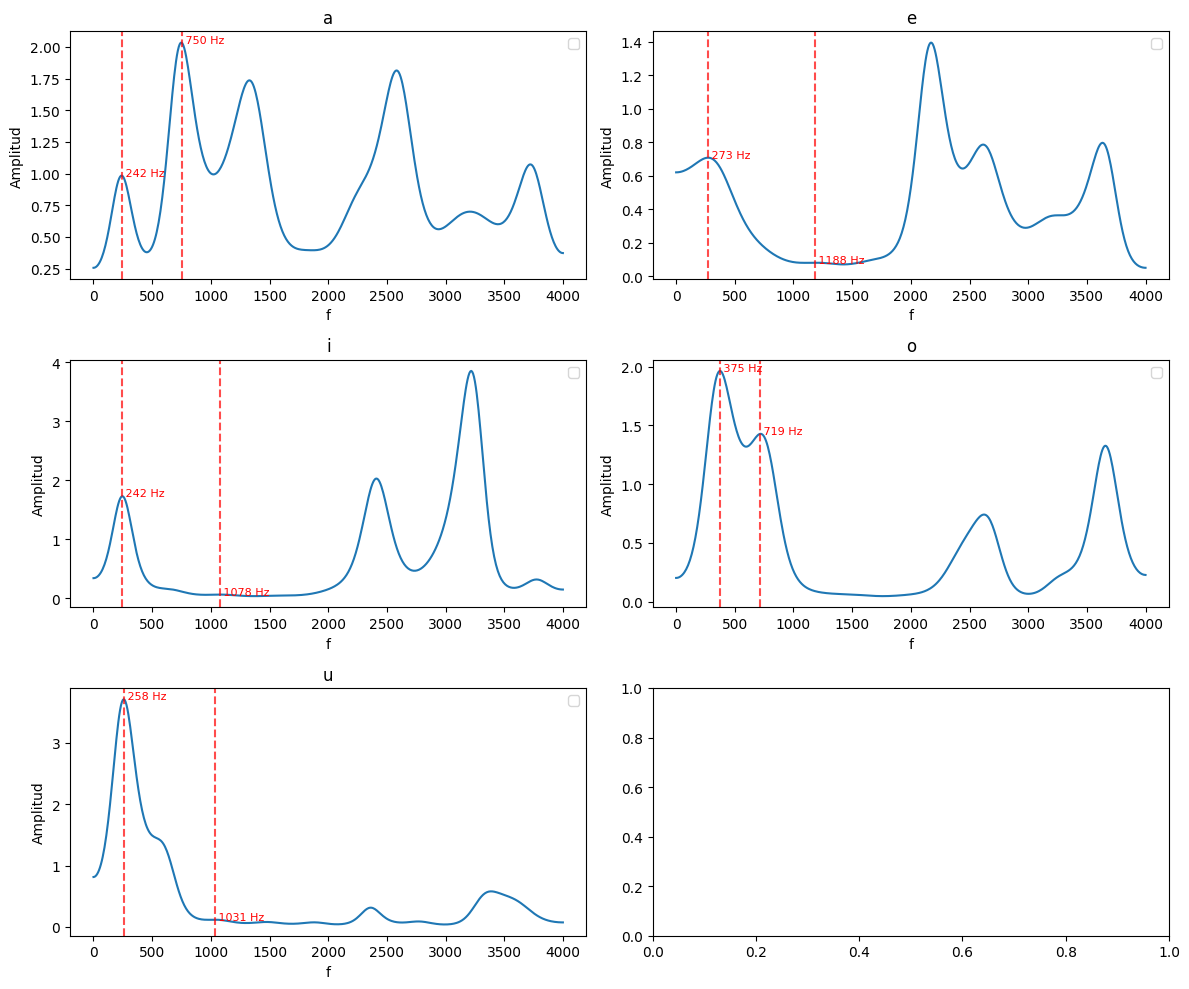

{'a': array([242, 750]), 'e': array([ 273, 1187]), 'i': array([ 242, 1078]), 'o': array([375, 718]), 'u': array([ 257, 1031])}


In [470]:
#Volvemos a frecuencia 

frecuencias_vocales_cepstrum = {}

h_frecuencial_20 = {}
freqs = np.linspace(0, fs/2, N//2 + 1)

for vocal, c_lifrado_20 in h_liftrado_20.items():  
    freq = cepstrum_to_freq(c_lifrado_20)
    h_frecuencial_20[vocal] = freq[:N//2+1]
    
fig, axes = plt.subplots(3, 2, figsize=(12,10))
axes = axes.flatten()

for ax, vocal in zip(axes, h_frecuencial_20.keys()):
    h = h_frecuencial_20[vocal]
    ax.plot(freqs, h)
    ax.set_title(f"{vocal}")
    ax.set_xlabel('f')
    ax.set_ylabel('Amplitud')
    ax.legend()
    
    #Grafico los picos
    picos, _ = find_peaks(h, distance=20)
    for p in picos[:2]:  # solo F1 y F2
        ax.axvline(x=freqs[p], color='red', linestyle='--', alpha=0.7)
        ax.text(freqs[p], h[p], f" {freqs[p]:.0f} Hz", color='red', fontsize=8)
        
    frecuencias_vocales_cepstrum[vocal] = freqs[picos[:2]].astype(int)
    
plt.tight_layout()
plt.show()

print(frecuencias_vocales_cepstrum)

## Ejercicio 2
Para cada una de las vocales identifique el sistema utilizando la t´ecni-
ca de predicci´on lineal, considerando un modelo AR de orden 12, y obtenga
las respuestas en frecuencia. Determine las formantes y compare los resulta-
dos con los obtenidos en el ejercicio anterio

In [471]:
orden = 12
N_fft = 1024
pc_coefs_vocal = {}
h_vocales = {}

for vocal, x in vocales.items():
    coefs = librosa.lpc(x, order=orden)
    pc_coefs_vocal[vocal] = coefs
    _, h = freqz([1], coefs, worN=N_fft//2+1, fs=fs)
    h_vocales[vocal] = h

/Users/juanmanueljuradokokoyaczuk/Documents/facultad/PDS/pds/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/juanmanueljuradokokoyaczuk/Documents/facultad/PDS/pds/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/var/folders/n0/_zbbdy_572bchcg3x3tncg0c0000gn/T/ipykernel_37310/2534631386.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/Users/juanmanueljuradokokoyaczuk/Documents/facultad/PDS/pds/.venv/lib/python3.13/site-packages/scipy/signal/_peak_finding.py:266: ComplexWarning: Casting complex values to real discards the imaginary part
  value = np.asarray(value, order='C', dtype=np.float64)
/Users/juanmanuelj

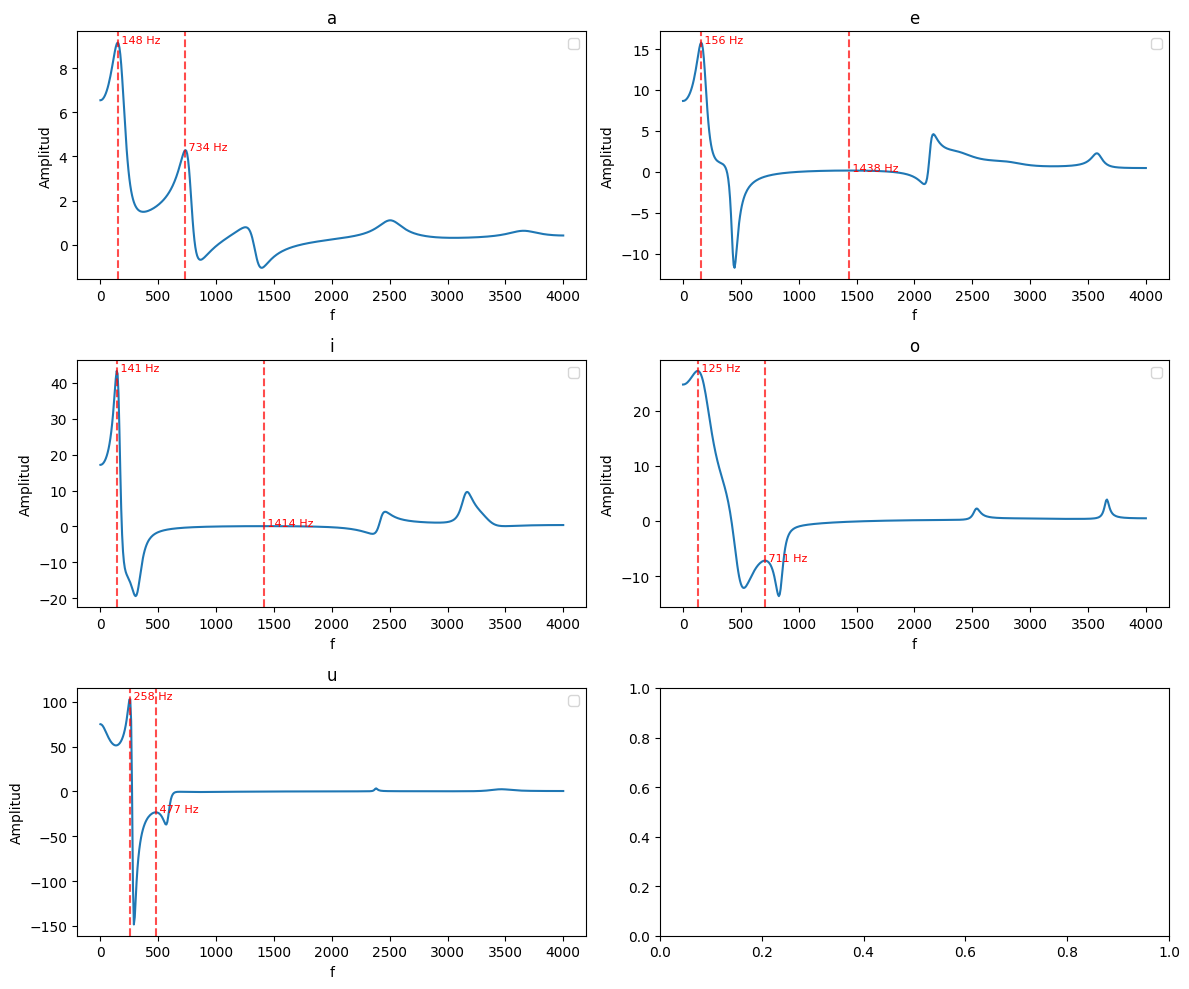

{'a': array([148, 734]), 'e': array([ 156, 1437]), 'i': array([ 140, 1414]), 'o': array([125, 710]), 'u': array([257, 476])}


In [472]:
freq_coef_lineales = {}
   
fig, axes = plt.subplots(3, 2, figsize=(12,10))
axes = axes.flatten()

for ax, vocal in zip(axes, h_vocales.keys()):
    h = h_vocales[vocal]
    ax.plot(freqs, h)
    ax.set_title(f"{vocal}")
    ax.set_xlabel('f')
    ax.set_ylabel('Amplitud')
    ax.legend()
    
    #Grafico los picos
    picos, _ = find_peaks(h, distance=20)
    for p in picos[:2]:  # solo F1 y F2
        ax.axvline(x=freqs[p], color='red', linestyle='--', alpha=0.7)
        ax.text(freqs[p], h[p], f" {freqs[p]:.0f} Hz", color='red', fontsize=8)
        
    freq_coef_lineales[vocal] = freqs[picos[:2]].astype(int)
    
plt.tight_layout()
plt.show()

print(freq_coef_lineales)

In [473]:
#Comparamos

vocales = frecuencias_vocales_cepstrum.keys()

for vocal in vocales:
    print(f"{vocal}:\n")
    print(f"Freqs. cepstrum: {frecuencias_vocales_cepstrum[vocal]}, ")
    print(f"Freqs. coef lineales: {freq_coef_lineales[vocal]}\n")

a:

Freqs. cepstrum: [242 750], 
Freqs. coef lineales: [148 734]

e:

Freqs. cepstrum: [ 273 1187], 
Freqs. coef lineales: [ 156 1437]

i:

Freqs. cepstrum: [ 242 1078], 
Freqs. coef lineales: [ 140 1414]

o:

Freqs. cepstrum: [375 718], 
Freqs. coef lineales: [125 710]

u:

Freqs. cepstrum: [ 257 1031], 
Freqs. coef lineales: [257 476]



## Ejercicio 3
En los archivos mic F01 sa2.wav y mic M01 sa1.wav se encuentran
los registros a 48 kHz de dos frases completas emitidas por un hablante feme-
nino y uno masculino, respectivamente. Sobre las mismas se desea comparar
diferentes t´ecnicas para la estimaci´on de la frecuencia fundamental (pitch o
F0). A partir de estas frases genere otras tres que contengan ruido blanco
aditivo con relaciones se˜nal ruido de 0, 20 y 50 dB.

In [482]:
x_f, fs_f = librosa.load('data/mic_F01_sa2.wav', sr=None)
x_m, fs_m = librosa.load('data/mic_M01_sa1.wav', sr=None)

In [483]:
def agregar_ruido(x, snr_db):
    P_señal = np.mean(x**2)
    P_ruido = P_señal / (10**(snr_db/10))
    ruido = np.random.randn(len(x)) * np.sqrt(P_ruido)
    return x + ruido

In [484]:
snrs = [0, 20, 50]

sennales_f = {snr: agregar_ruido(x_f, snr) for snr in snrs}
sennales_m = {snr: agregar_ruido(x_m, snr) for snr in snrs}

sennales_f['original'] = x_f
sennales_m['original'] = x_m

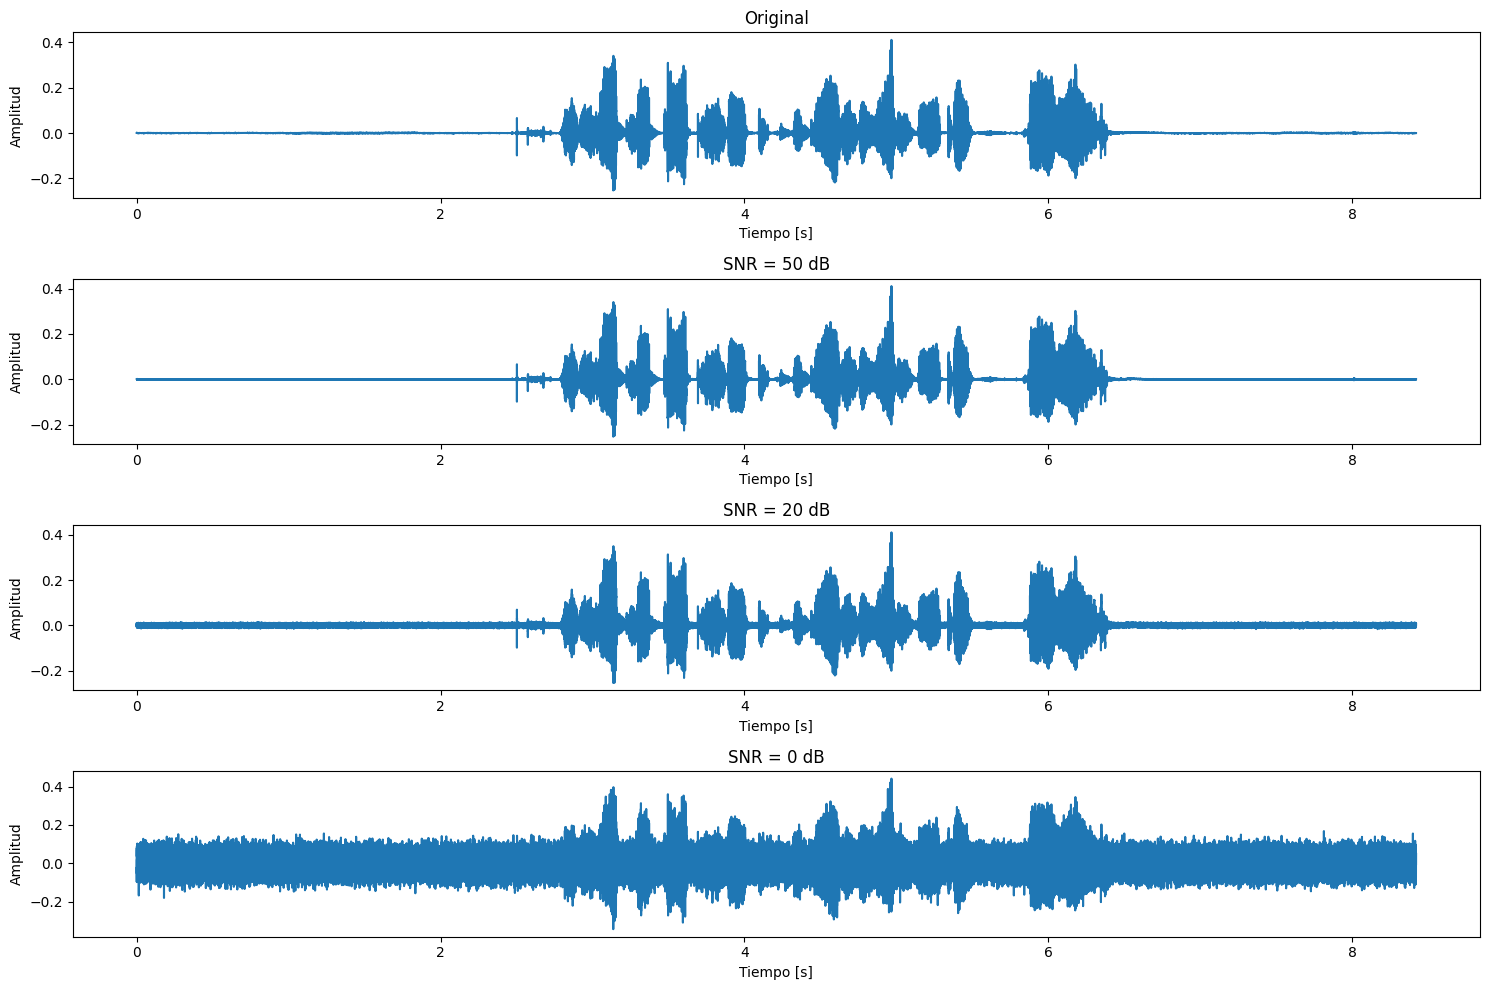

In [485]:
fig, axes = plt.subplots(4, 1, figsize=(15, 10))

etiquetas = ['original', 50, 20, 0]

for ax, etiqueta in zip(axes, etiquetas):
    señal = sennales_m[etiqueta]
    t = np.arange(len(señal)) / fs_m
    ax.plot(t, señal)
    ax.set_title(f'SNR = {etiqueta} dB' if etiqueta != 'original' else 'Original')
    ax.set_xlabel('Tiempo [s]')
    ax.set_ylabel('Amplitud')

plt.tight_layout()
plt.show()

a) Realice la estimaci´on del pitch (F0) por tramos mediante la t´ecnica
de autocorrelaci´on temporal, considerando tanto las se˜nales con ruido como
la original.

In [503]:
ref_m = np.loadtxt('data/ref_M01_sa1.f0')

In [504]:
fs = fs_m
hop_ms = 10
hop_s = hop_ms / 1000
hop_muestras = int(hop_s * fs)

frame_ms = 32
frame_s = frame_ms / 1000
frame_muestras = int(frame_s * fs)

inicio_muestras = int(0.016 * fs)  # 16ms de offset inicial

In [507]:
f0_autocorr = []
f0_cepstrum = []

f0_min, f0_max = 100, 300
lag_min = int(fs / f0_max)
lag_max = int(fs / f0_min)

for i in range(len(ref_m)):
    inicio = inicio_muestras + i * hop_muestras
    ventana = x_m[inicio:inicio + frame_muestras]
    
    es_sonoro = ref_m[i, 1] > 0.5
    
    if not es_sonoro:
        f0_autocorr.append(0)
        f0_cepstrum.append(0)
    else:
        # Autocorrelación
        ac = np.correlate(ventana, ventana, mode='full')
        ac = ac[len(ac)//2:]
        lag_pico = np.argmax(ac[lag_min:lag_max]) + lag_min
        f0_autocorr.append(fs / lag_pico)
        
        # Cepstrum
        cep = np.fft.ifft(np.log(np.abs(np.fft.fft(ventana)))).real
        lag_pico = np.argmax(cep[lag_min:lag_max]) + lag_min
        f0_cepstrum.append(fs / lag_pico)

f0_autocorr = np.array(f0_autocorr)
f0_cepstrum = np.array(f0_cepstrum)

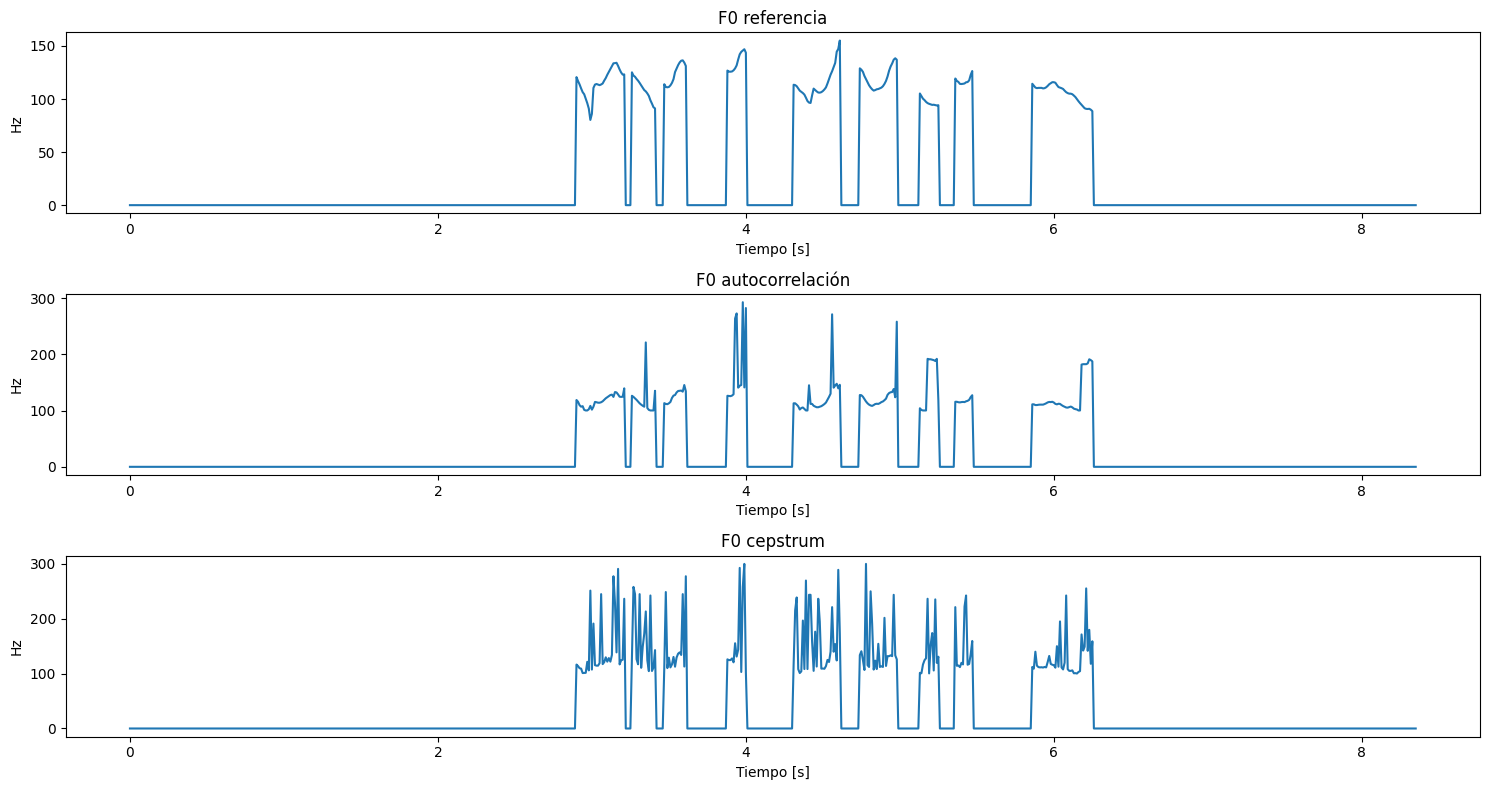

In [508]:
fig, axes = plt.subplots(3, 1, figsize=(15, 8))

tiempo = np.arange(len(ref_m)) * hop_ms / 1000  # eje temporal en segundos

axes[0].plot(tiempo, ref_m[:, 0])
axes[0].set_title('F0 referencia')
axes[0].set_ylabel('Hz')

axes[1].plot(tiempo, f0_autocorr)
axes[1].set_title('F0 autocorrelación')
axes[1].set_ylabel('Hz')

axes[2].plot(tiempo, f0_cepstrum)
axes[2].set_title('F0 cepstrum')
axes[2].set_ylabel('Hz')

for ax in axes:
    ax.set_xlabel('Tiempo [s]')

plt.tight_layout()
plt.show()